In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
print("24BAD048-Jeevaprakash S")

24BAD048-Jeevaprakash S


In [ ]:
data = pd.read_csv("Mall_Customers.csv")
print(data.head())

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [ ]:
print("\nMissing Values:\n", data.isnull().sum())
X = data[['Annual Income (k$)', 'Spending Score (1-100)']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



Missing Values:
 CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


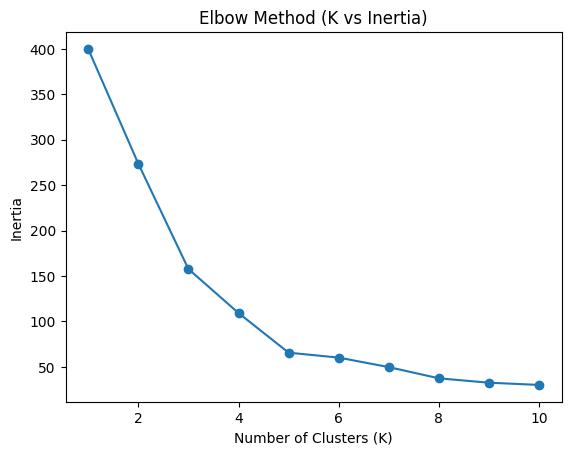

In [ ]:
inertia = []
K_range = range(1, 11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    inertia.append(model.inertia_)

plt.figure()
plt.plot(K_range, inertia, marker='o')
plt.title("Elbow Method (K vs Inertia)")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=5, random_state=42)
labels = kmeans.fit_predict(X_scaled)
data['Cluster'] = labels

In [ ]:
print("\nInertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, labels))


Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


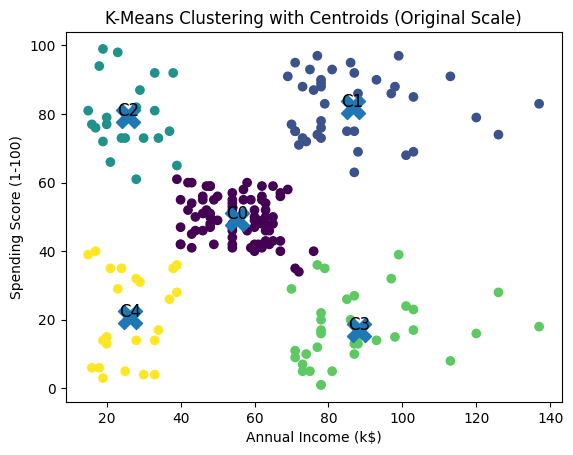

In [ ]:
X_original = scaler.inverse_transform(X_scaled)
centroids = scaler.inverse_transform(kmeans.cluster_centers_)

plt.figure()
plt.scatter(X_original[:, 0], X_original[:, 1], c=labels)
plt.scatter(centroids[:, 0], centroids[:, 1], s=300, marker='X')

for i, (x, y) in enumerate(centroids):
    plt.text(x, y, f'C{i}', fontsize=12, ha='center')
plt.title("K-Means Clustering with Centroids (Original Scale)")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.show()


In [ ]:
#Print Centroids
print("\nCentroids (scaled values):\n", centroids)

#Cluster Interpretation
print("\nCluster-wise Mean Values:")
print(data.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean())

print("\nGender Distribution:")
print(data.groupby('Cluster')['Gender'].value_counts())


Centroids (scaled values):
 [[55.2962963  49.51851852]
 [86.53846154 82.12820513]
 [25.72727273 79.36363636]
 [88.2        17.11428571]
 [26.30434783 20.91304348]]

Cluster-wise Mean Values:
               Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                       
0        42.716049           55.296296               49.518519
1        32.692308           86.538462               82.128205
2        25.272727           25.727273               79.363636
3        41.114286           88.200000               17.114286
4        45.217391           26.304348               20.913043

Gender Distribution:
Cluster  Gender
0        Female    48
         Male      33
1        Female    21
         Male      18
2        Female    13
         Male       9
3        Male      19
         Female    16
4        Female    14
         Male       9
Name: count, dtype: int64
